1. Data Cleaning & Preprocessing
To ensure accurate analysis, the following steps were taken:

Data Types: Released_Year was converted to integers (handling non-numeric values), Runtime was stripped of the " min" suffix and converted to integers, and Gross revenue was cleaned of commas and cast to floats.

Missing Values: Missing entries in Meta_score and Gross were imputed using their respective median values to preserve the dataset size while minimizing bias.

Feature Extraction: Since the Genre column often contained multiple labels (e.g., "Action, Sci-Fi"), a Main_Genre feature was created using the first genre listed for more effective grouping.

2. Key Insights
Rating Trends: The line plot shows the evolution of average ratings over the years. We observe higher average ratings for early cinema (fewer films made, mostly masterpieces preserved) and more stabilized ratings in recent decades.

Genre Popularity: Drama is by far the most represented genre in the top 1000 list, followed by Comedy and Crime.

Correlation Findings: The heatmap reveals a moderate positive correlation between No_of_Votes and Gross revenue, suggesting that popular movies (highly voted) also tend to be commercial successes.

Director Impact: The scatter plot shows that directors with higher movie counts in the top 1000 (like Spielberg or Hitchcock) consistently maintain high average ratings, illustrating sustained excellence.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load and Inspect
df = pd.read_csv('imdb_top_1000.csv')

# 2. Data Preprocessing
# Convert types and clean strings
df['Released_Year'] = pd.to_numeric(df['Released_Year'], errors='coerce')
df = df.dropna(subset=['Released_Year'])
df['Runtime'] = df['Runtime'].str.replace(' min', '').astype(int)
df['Gross'] = df['Gross'].str.replace(',', '')
df['Gross'] = pd.to_numeric(df['Gross'], errors='coerce')



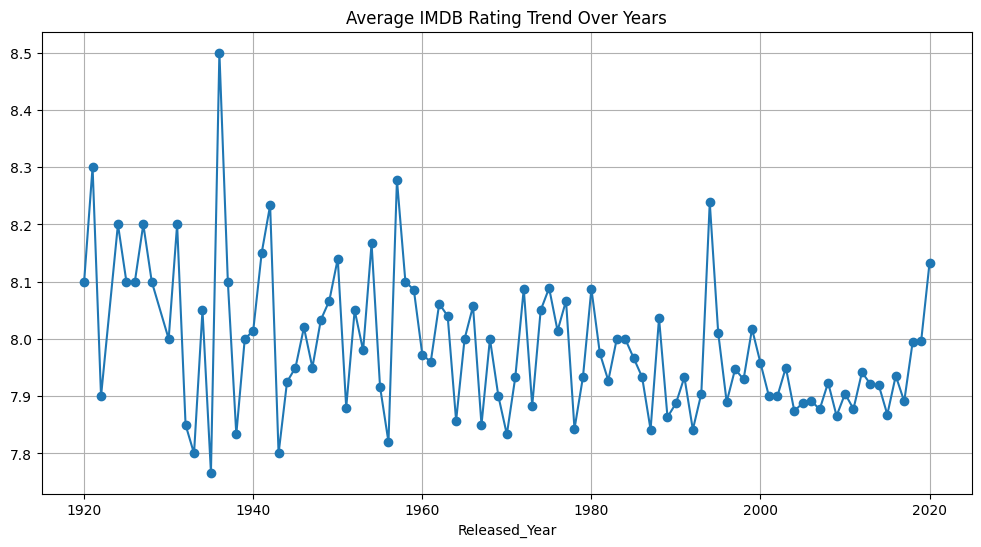

In [3]:
# Handle missing values
df['Meta_score'] = df['Meta_score'].fillna(df['Meta_score'].median())
df['Gross'] = df['Gross'].fillna(df['Gross'].median())
df['Main_Genre'] = df['Genre'].str.split(',').str[0]

# 3. Rating Trends Over Years (Line Plot)
plt.figure(figsize=(12, 6))
df.groupby('Released_Year')['IMDB_Rating'].mean().plot(kind='line', marker='o')
plt.title('Average IMDB Rating Trend Over Years')
plt.grid(True)
plt.show()



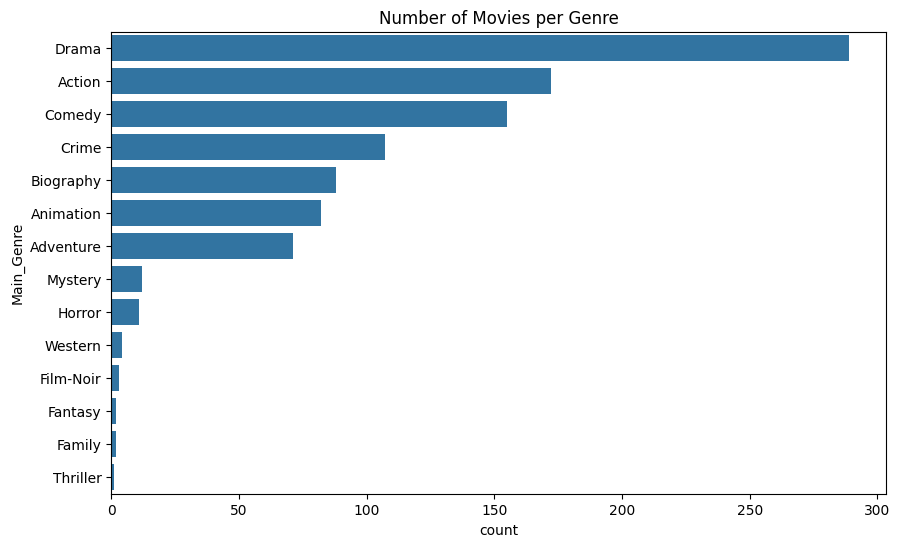

In [4]:
# 4. Genre Popularity (Bar Plot)
plt.figure(figsize=(10, 6))
sns.countplot(data=df, y='Main_Genre', order=df['Main_Genre'].value_counts().index)
plt.title('Number of Movies per Genre')
plt.show()



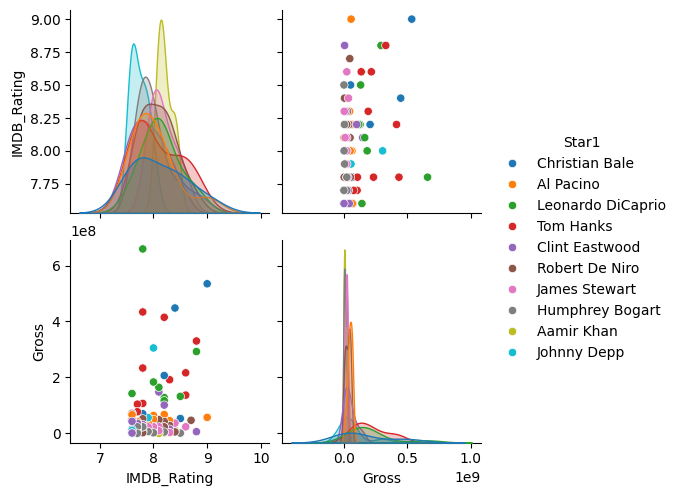

In [5]:
# 5. Star Power (Pair Plot)
# Focus on Star1 and Top 10 Actors for clarity
top_stars = df['Star1'].value_counts().nlargest(10).index
sns.pairplot(df[df['Star1'].isin(top_stars)][['Star1', 'IMDB_Rating', 'Gross']], hue='Star1')
plt.show()



Text(0.5, 1.0, 'Correlation Heatmap')

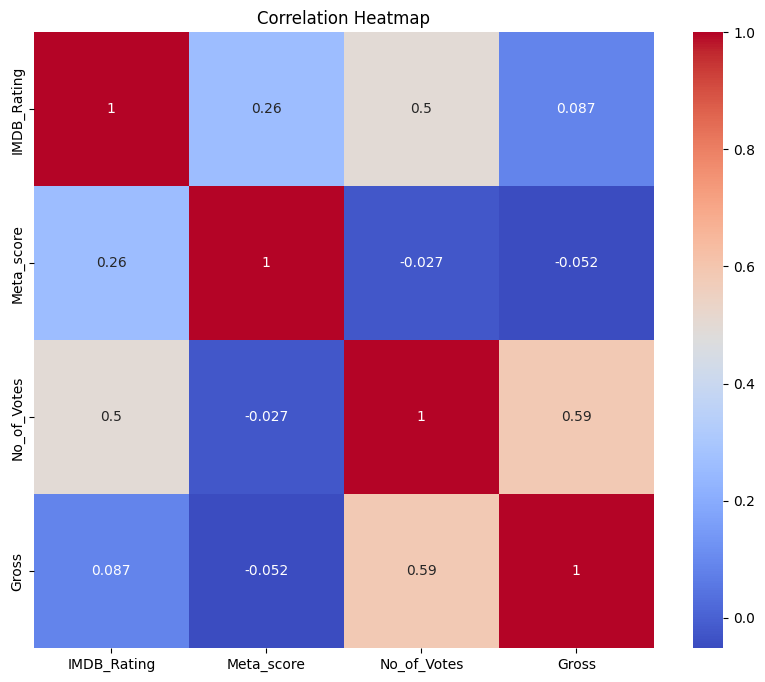

In [6]:
# 6. Correlation Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df[['IMDB_Rating', 'Meta_score', 'No_of_Votes', 'Gross']].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')